# Figure 4

![Full Figure](../figures/fig04_FULL.png)

## Code For Figure 4A–D: Extended Post-Probe Performance

**Goal:** Show that FixGrower-trained animals maintain robust task performance over extended periods after probe stage completion.

| Panel | Description | Data source |
|-------|-------------|-------------|
| A | Example fixation-duration sequence (R043), session boundaries | `fixgrower_continued_stage11.parquet` |
| B | Session fixation-duration histogram + truncated exponential PDF (τ = 1.2 s, 1–2 s) | `fixgrower_continued_stage11.parquet` |
| C | Daily mean violation rate vs days post-probe (SEM across animals) | `fixgrower_continued_stage11.parquet` |
| D | 100-day violation-rate summary: box + one gray dot per animal-day | `fixgrower_continued_stage11.parquet` |

**Outputs:** `figures/fig04a_example_fix_durations.png`, `fig04b_fixation_duration_distribution.png`, `fig04c_violation_rate_post_probe.png`, `fig04d_violation_rate_summary.png`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from fixation_grower import config
from fixation_grower.io import load_fixgrower_continued_df
from fixation_grower.plotting import save_figure
from fixation_grower.transforms import (
    add_days_since_probe_end,
    make_stage11_daily_summary_df,
    make_stage11_session_fix_dur_df,
)

sns.set_context(
    "notebook",
    rc={
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "axes.titleweight": "bold",
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "lines.linewidth": 2,
        "lines.markersize": 7,
    },
)

In [2]:
continued_df = load_fixgrower_continued_df()
continued_df = add_days_since_probe_end(continued_df)

daily_summary_df = make_stage11_daily_summary_df(continued_df)
session_fix_dur_df = make_stage11_session_fix_dur_df(continued_df)

## Panel A — Example fixation durations

Trial-level fixation requirements for `config.FIXGROWER_DEMO_ANIMAL` (R043) over the first seven post-probe days. Dashed vertical lines mark session boundaries.

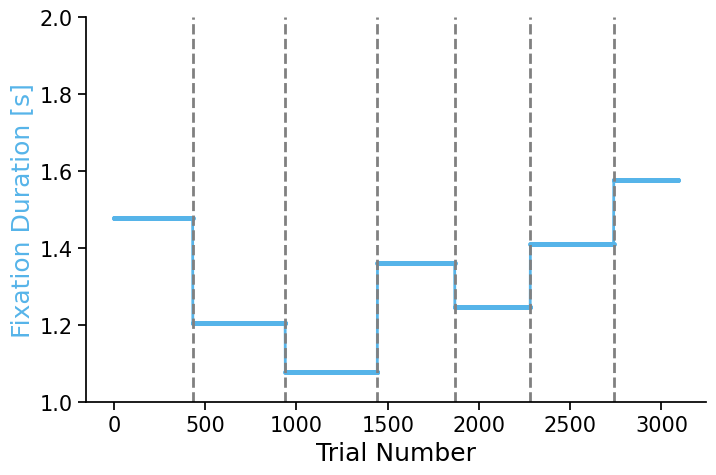

In [3]:
example_df = continued_df.query(
    "animal_id == @config.FIXGROWER_DEMO_ANIMAL"
).copy()
example_df["cumulative_trial"] = (
    example_df.groupby("animal_id").trial.cumcount() + 1
)

plot_df = example_df.query(
    "days_relative_to_stage_11_adj <= @config.STAGE11_EXAMPLE_SESSIONS"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.despine(ax=ax)
sns.lineplot(
    data=plot_df,
    x="cumulative_trial",
    y="fixation_dur",
    color=config.FIXGROWER_COLOR,
    marker=".",
    markeredgecolor="none",
    lw=2,
    ax=ax,
)

session_starts = plot_df.groupby("sess_id")["cumulative_trial"].min() - 1
for session_start in session_starts:
    if session_start > 0:
        ax.axvline(x=session_start, color="gray", linestyle="--", lw=2)

ax.set(xlabel="Trial Number", ylim=(1, 2))
ax.set_ylabel("Fixation Duration [s]", color=config.FIXGROWER_COLOR)
save_figure(fig, "fig04a_example_fix_durations")

## Panel B — Fixation duration distribution

Per-session maximum fixation duration across all animals and sessions within the 100-day assessment window. Overlaid curve is the theoretical truncated exponential PDF (τ = 1.2 s, bounds 1–2 s).

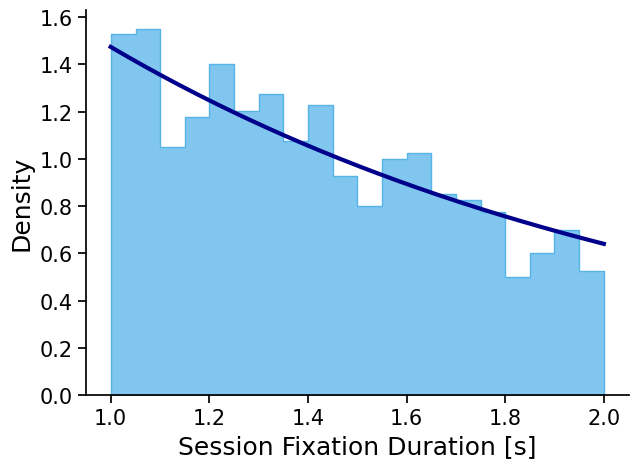

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.despine(ax=ax)
sns.histplot(
    data=session_fix_dur_df,
    x="fixation_dur",
    binwidth=0.05,
    color=config.FIXGROWER_COLOR,
    element="step",
    stat="density",
    ax=ax,
)

tau = config.STAGE11_TRUNCATED_EXP_TAU
a, b = config.STAGE11_TRUNCATED_EXP_MIN, config.STAGE11_TRUNCATED_EXP_MAX
x = np.linspace(a, b, 200)
z = np.exp(-a / tau) - np.exp(-b / tau)
pdf = (1 / tau) * np.exp(-x / tau) / z
ax.plot(x, pdf, lw=3, color="darkblue")

ax.set_xlabel("Session Fixation Duration [s]")
save_figure(fig, "fig04b_fixation_duration_distribution")

## Panel C — Violation rate over days post-probe

Each point is the mean violation rate across animals for that day; shading is SEM across animals.

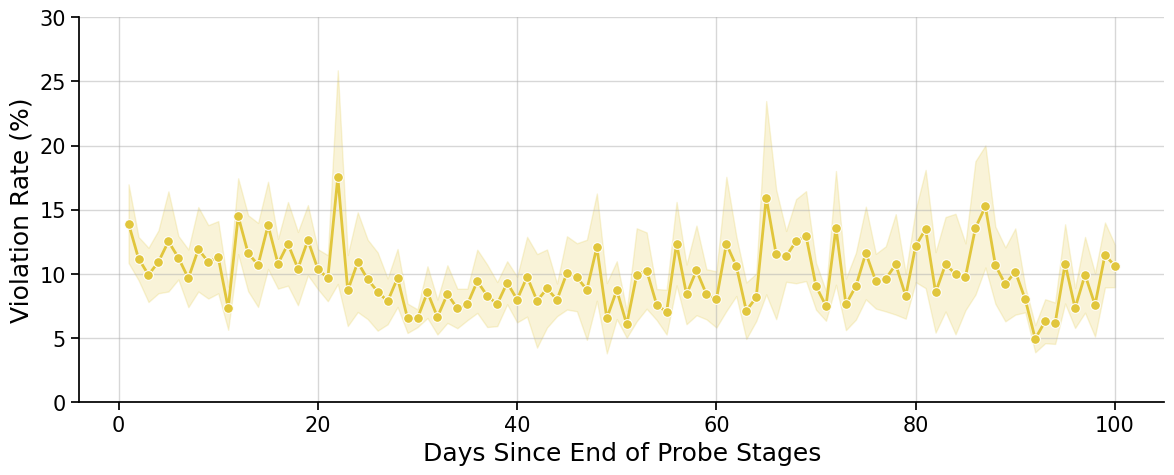

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(
    data=daily_summary_df,
    x="days_relative_to_stage_11_adj",
    y="violation_rate",
    ax=ax,
    errorbar="se",
    marker="o",
    color=config.VIOLATION_COLOR,
)
ax.grid(True, alpha=0.5)
ax.set(
    xlabel="Days Since End of Probe Stages",
    ylabel="Violation Rate (%)",
    ylim=(0, 30),
)
sns.despine(ax=ax)
save_figure(fig, "fig04c_violation_rate_post_probe")

### Panel C descriptive summary

In [7]:
daily_summary_df["violation_rate"].agg(["median", "mean", "std", "count"])

median      7.269217
mean        9.896779
std         8.259429
count     800.000000
Name: violation_rate, dtype: float64

## Panel D — Violation rate summary

Box spans the interquartile range with a line at the median. Each gray dot is one animal-day (mean violation rate for that animal on that day).

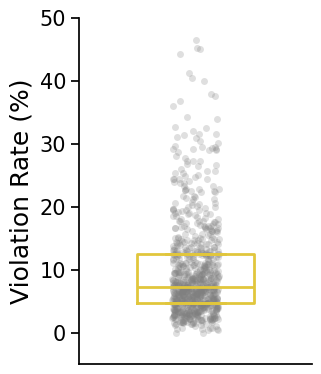

In [8]:
fig, ax = plt.subplots(figsize=(3, 4.5))
sns.despine(ax=ax)

sns.boxplot(
    y="violation_rate",
    data=daily_summary_df,
    ax=ax,
    color=config.VIOLATION_COLOR,
    fill=False,
    showfliers=False,
    whis=0,
    width=0.5,
    zorder=10,
)
sns.stripplot(
    y="violation_rate",
    data=daily_summary_df,
    ax=ax,
    color="gray",
    alpha=0.25,
)
ax.set(ylabel="Violation Rate (%)", ylim=(-5, 50), xticks=[])
save_figure(fig, "fig04d_violation_rate_summary")